In [79]:
import kagglehub
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.exceptions import ConvergenceWarning
from feature_engine.encoding import OneHotEncoder
from feature_engine.transformation import YeoJohnsonTransformer
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)
mpl.rcParams['figure.dpi'] = 150

In [80]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
data_path = os.listdir(path)[0]
full_path = os.path.join(path, data_path)
print(f"Full Path: {full_path}")

In [81]:
df = pd.read_csv(full_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [82]:
df.shape

(7043, 21)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [84]:
cols_description = [
    'Customer ID', 'Whether the customer is a male or a female', 
    'Whether the customer is a senior citizen or not (1, 0)', 
    'Whether the customer has a partner or not (Yes, No)', 
    'Whether the customer has dependents or not (Yes, No)',
    'Number of months the customer has stayed with the company',
    'Whether the customer has a phone service or not (Yes, No)',
    'Whether the customer has multiple lines or not (Yes, No, No phone service)',
    'Customer’s internet service provider (DSL, Fiber optic, No)',
    'Whether the customer has online security or not (Yes, No, No internet service)',
    'Whether the customer has online backup or not (Yes, No, No internet service)',
    'Whether the customer has device protection or not (Yes, No, No internet service)',
    'Whether the customer has tech support or not (Yes, No, No internet service)',
    'Whether the customer has streaming TV or not (Yes, No, No internet service)',
    'Whether the customer has streaming movies or not (Yes, No, No internet service)',
    'The contract term of the customer (Month-to-month, One year, Two year)',
    'Whether the customer has paperless billing or not (Yes, No)',
    'The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card',
    'The amount charged to the customer monthly',
    'The total amount charged to the customer',
    'Whether the customer churned or not (Yes or No)'
]

for i, (col, desc) in enumerate(zip(df.columns, cols_description)):
    print(f"Column {i}: {col}")
    print(f'Description: {desc}', '\n')
    print('-*'*50, '\n')

Column 0: customerID
Description: Customer ID 

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column 1: gender
Description: Whether the customer is a male or a female 

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column 2: SeniorCitizen
Description: Whether the customer is a senior citizen or not (1, 0) 

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column 3: Partner
Description: Whether the customer has a partner or not (Yes, No) 

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column 4: Dependents
Description: Whether the customer has dependents or not (Yes, No) 

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column 5: tenure
Description: Number of months the customer has stayed with the company 

-*-*

In [85]:
totalCharges_mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
none_numeric_vals = df.loc[totalCharges_mask, 'TotalCharges'].unique()

print(f"TotalCharges Column Bad Values : {none_numeric_vals}")

TotalCharges Column Bad Values : [' ']


In [86]:
df = df[~totalCharges_mask]
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
print(f"TotalCharges Column New DataType: {df['TotalCharges'].dtype}")

TotalCharges Column New DataType: float64


In [87]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
print(f'SeniorCitizen Column New Values:', df['SeniorCitizen'].unique())

SeniorCitizen Column New Values: ['No' 'Yes']


In [88]:
customer_ids = df['customerID']
df.drop(columns='customerID', inplace=True, errors='ignore')

In [89]:
numeric_cols = df.select_dtypes(include='number')
numeric_cols.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [90]:
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    print(f'Column {col} Values:')
    print(df[col].value_counts(), ' \n')
    print('-*'*50, '\n')

Column gender Values:
gender
Male      3549
Female    3483
Name: count, dtype: int64  

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column SeniorCitizen Values:
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64  

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column Partner Values:
Partner
No     3639
Yes    3393
Name: count, dtype: int64  

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column Dependents Values:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64  

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column PhoneService Values:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64  

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* 

Column MultipleLines Values:
Mult

In [91]:
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette('cubehelix')

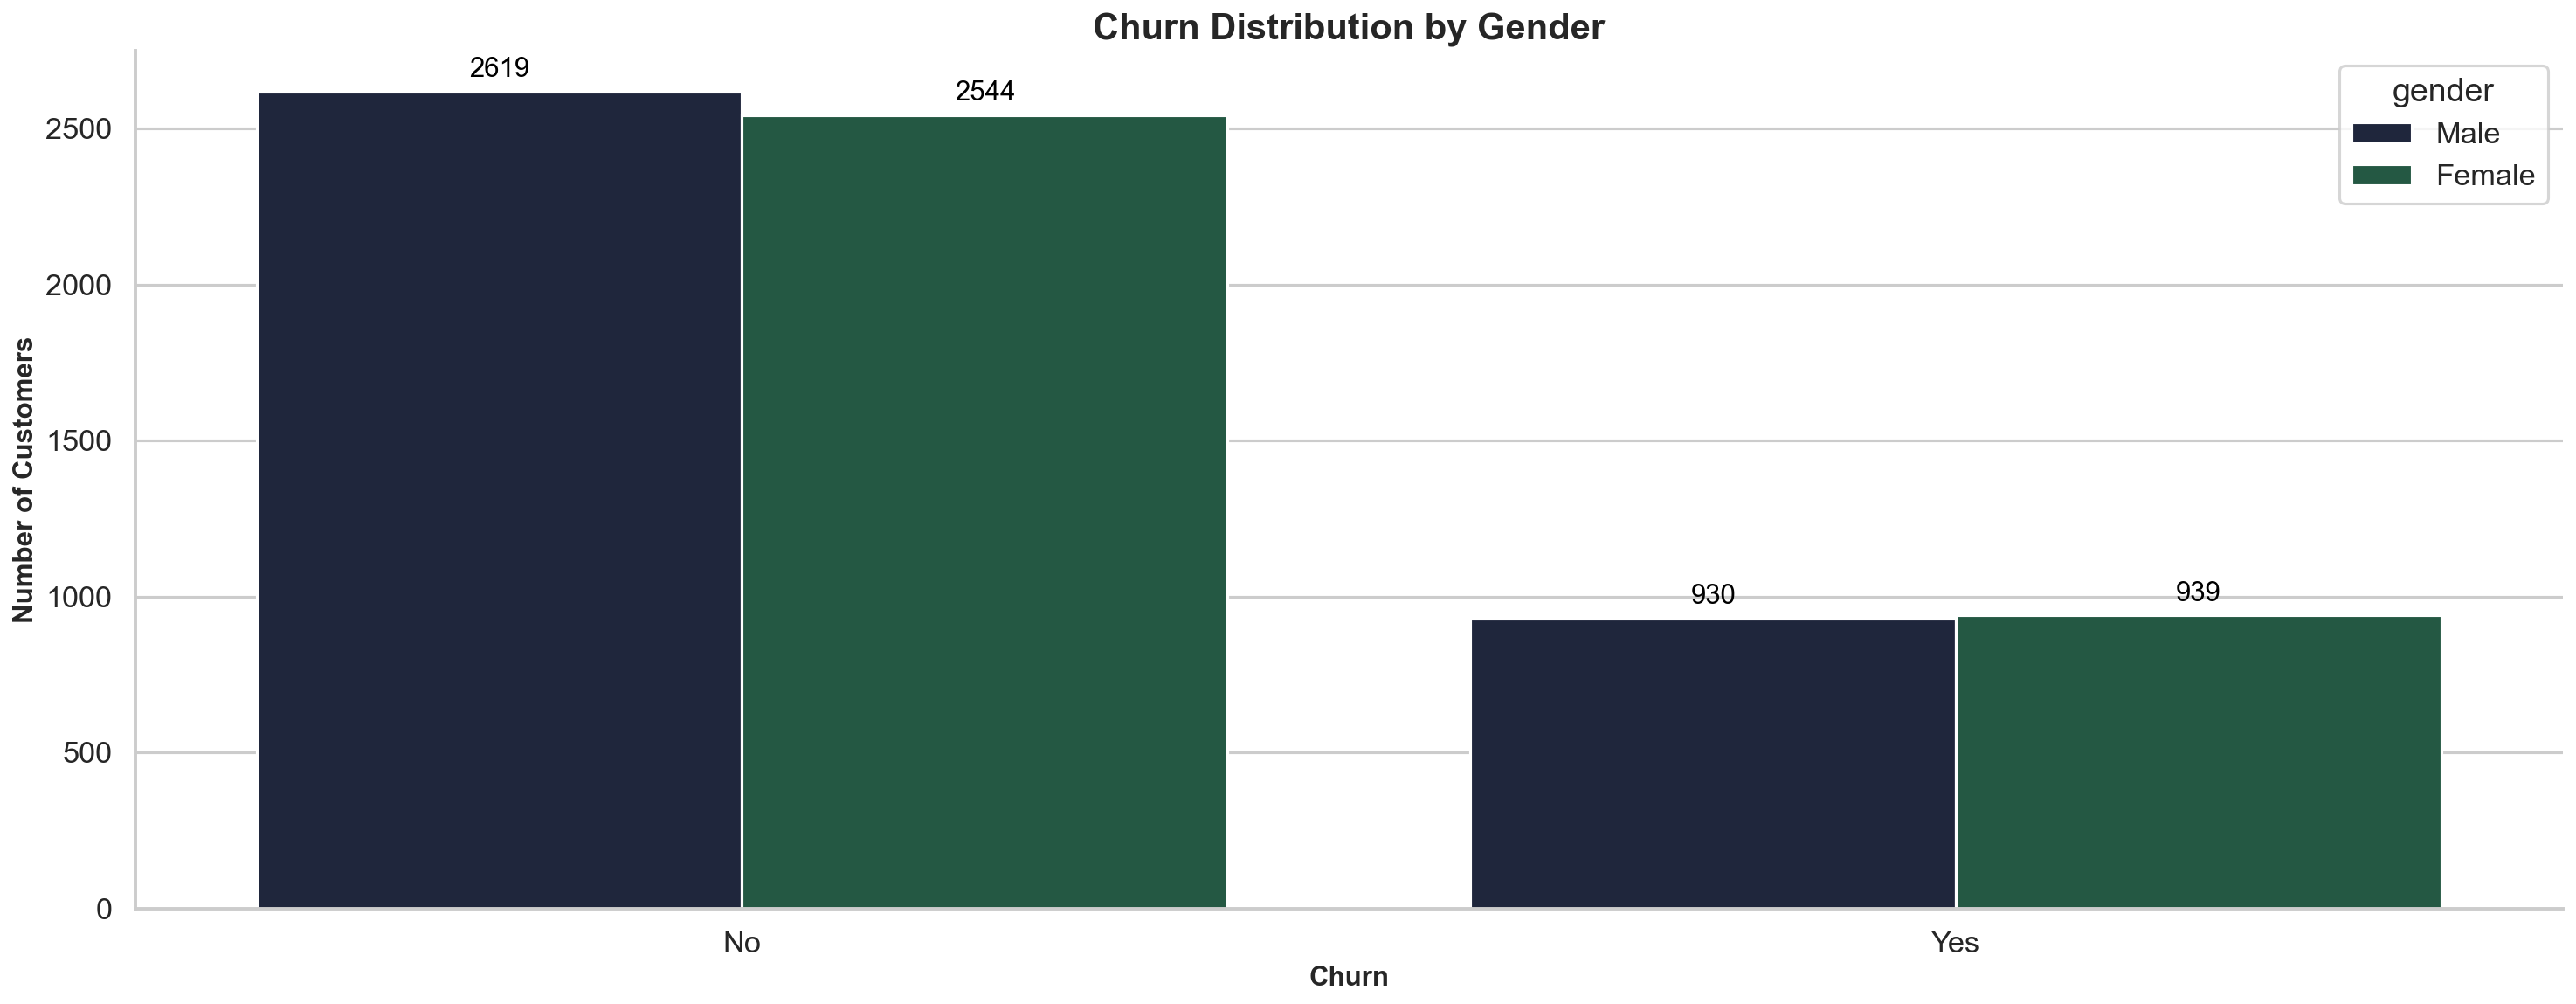

In [92]:
plt.figure(figsize=(20,8))
churn_by_genders = df.groupby('Churn')['gender'].value_counts().reset_index(name='count')

ax = sns.barplot(data=churn_by_genders, x='Churn', y='count', hue='gender')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(int(height), ((p.get_x() + p.get_width() / 2), height),
                    ha='center', va='bottom', fontsize=15, color="black", xytext=(0,5), textcoords="offset points")

sns.despine()
plt.title("Churn Distribution by Gender", fontsize=20, fontweight="bold")
plt.xlabel('Churn', fontweight="bold", fontsize=15)
plt.ylabel("Number of Customers", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

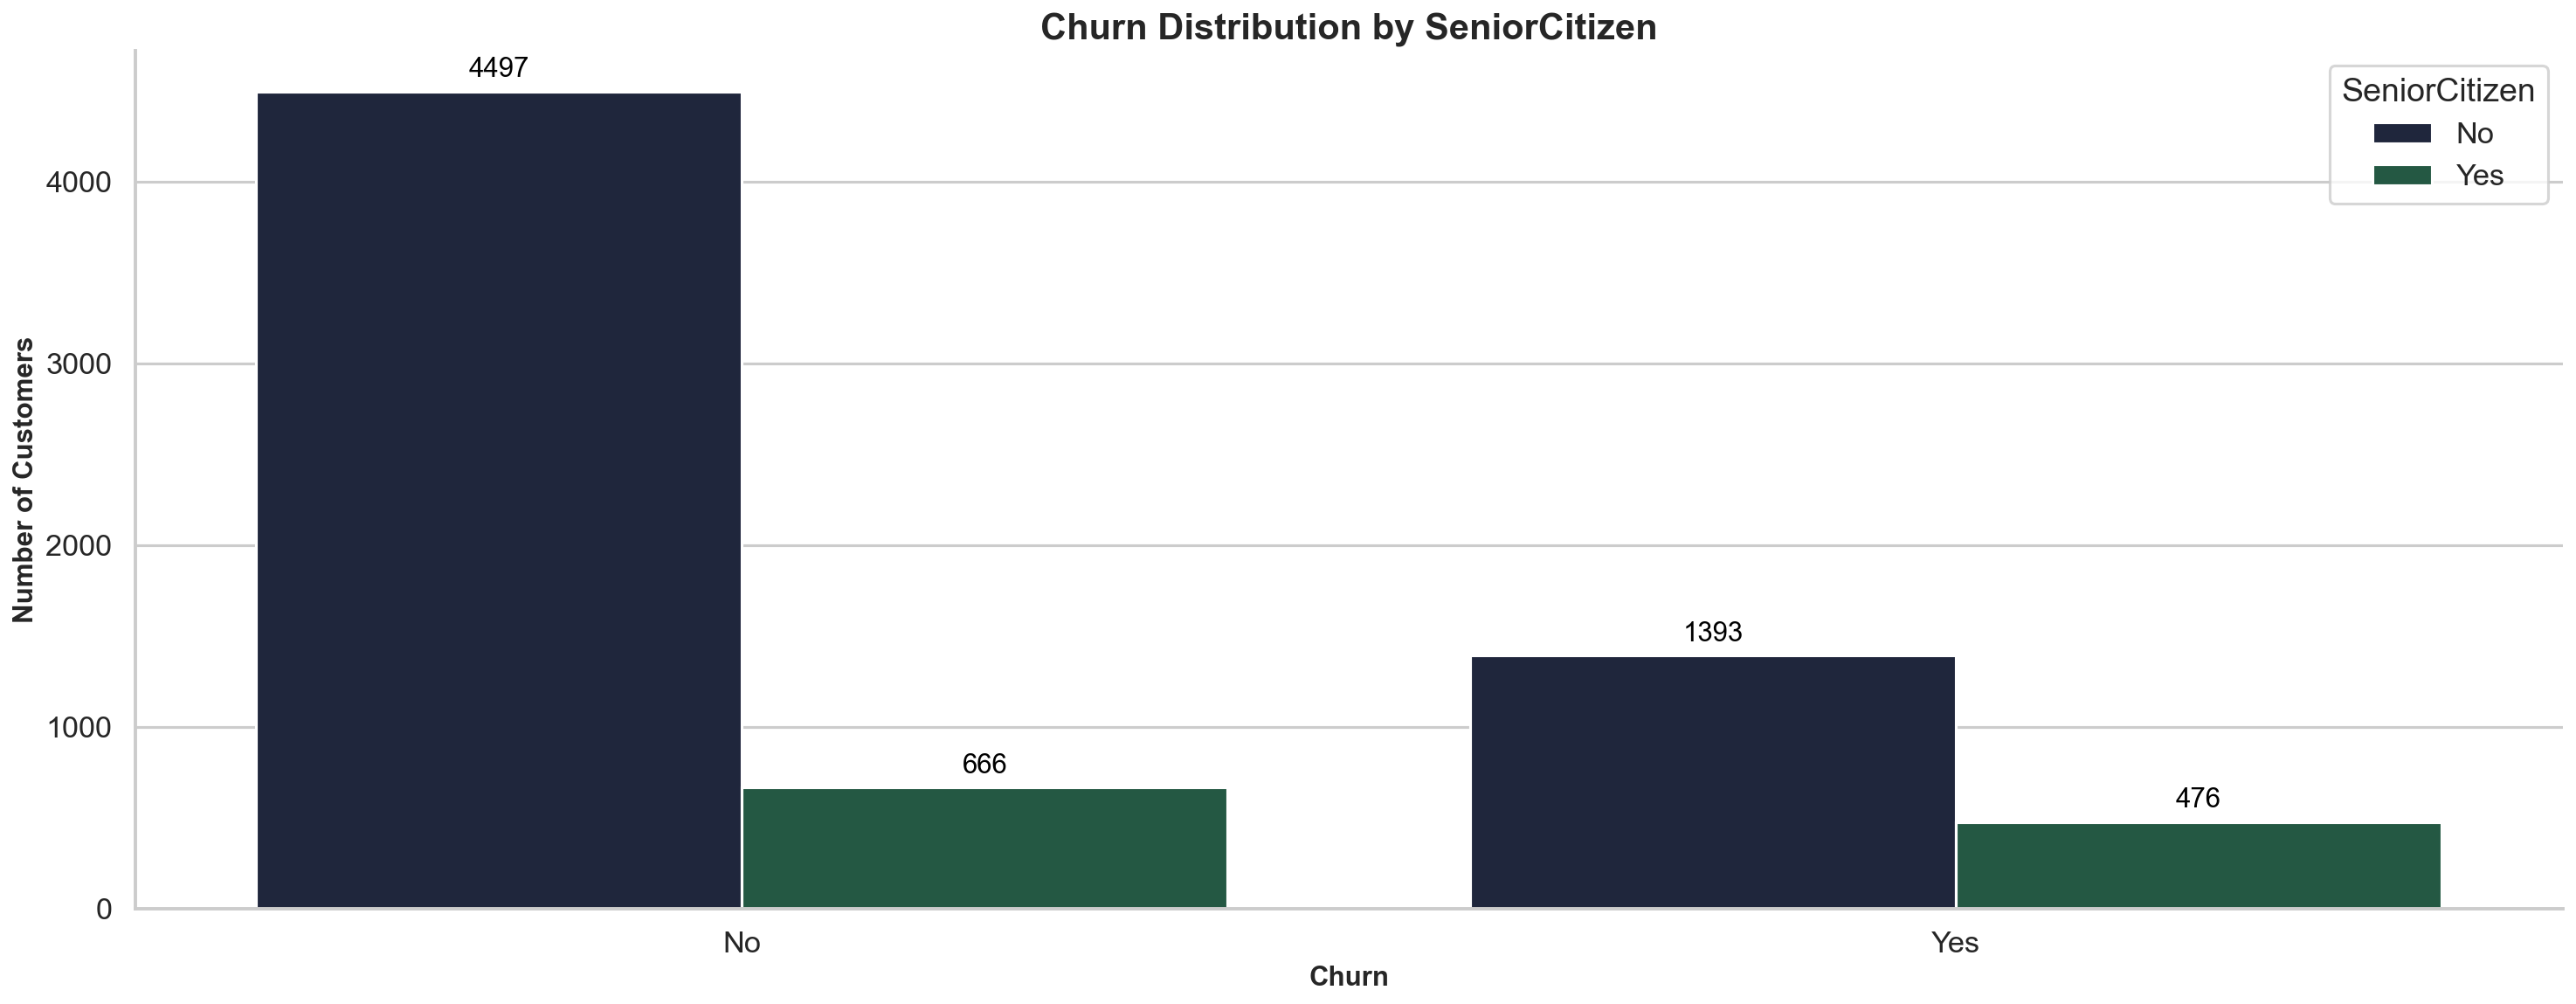

In [93]:
plt.figure(figsize=(20,8))
churn_by_genders = df.groupby('Churn')['SeniorCitizen'].value_counts().reset_index(name='count')

ax = sns.barplot(data=churn_by_genders, x='Churn', y='count', hue='SeniorCitizen')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(int(height), ((p.get_x() + p.get_width() / 2), height),
                    ha='center', va='bottom', fontsize=15, color="black", xytext=(0,5), textcoords="offset points")

sns.despine()
plt.title("Churn Distribution by SeniorCitizen", fontsize=20, fontweight="bold")
plt.xlabel('Churn', fontweight="bold", fontsize=15)
plt.ylabel("Number of Customers", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

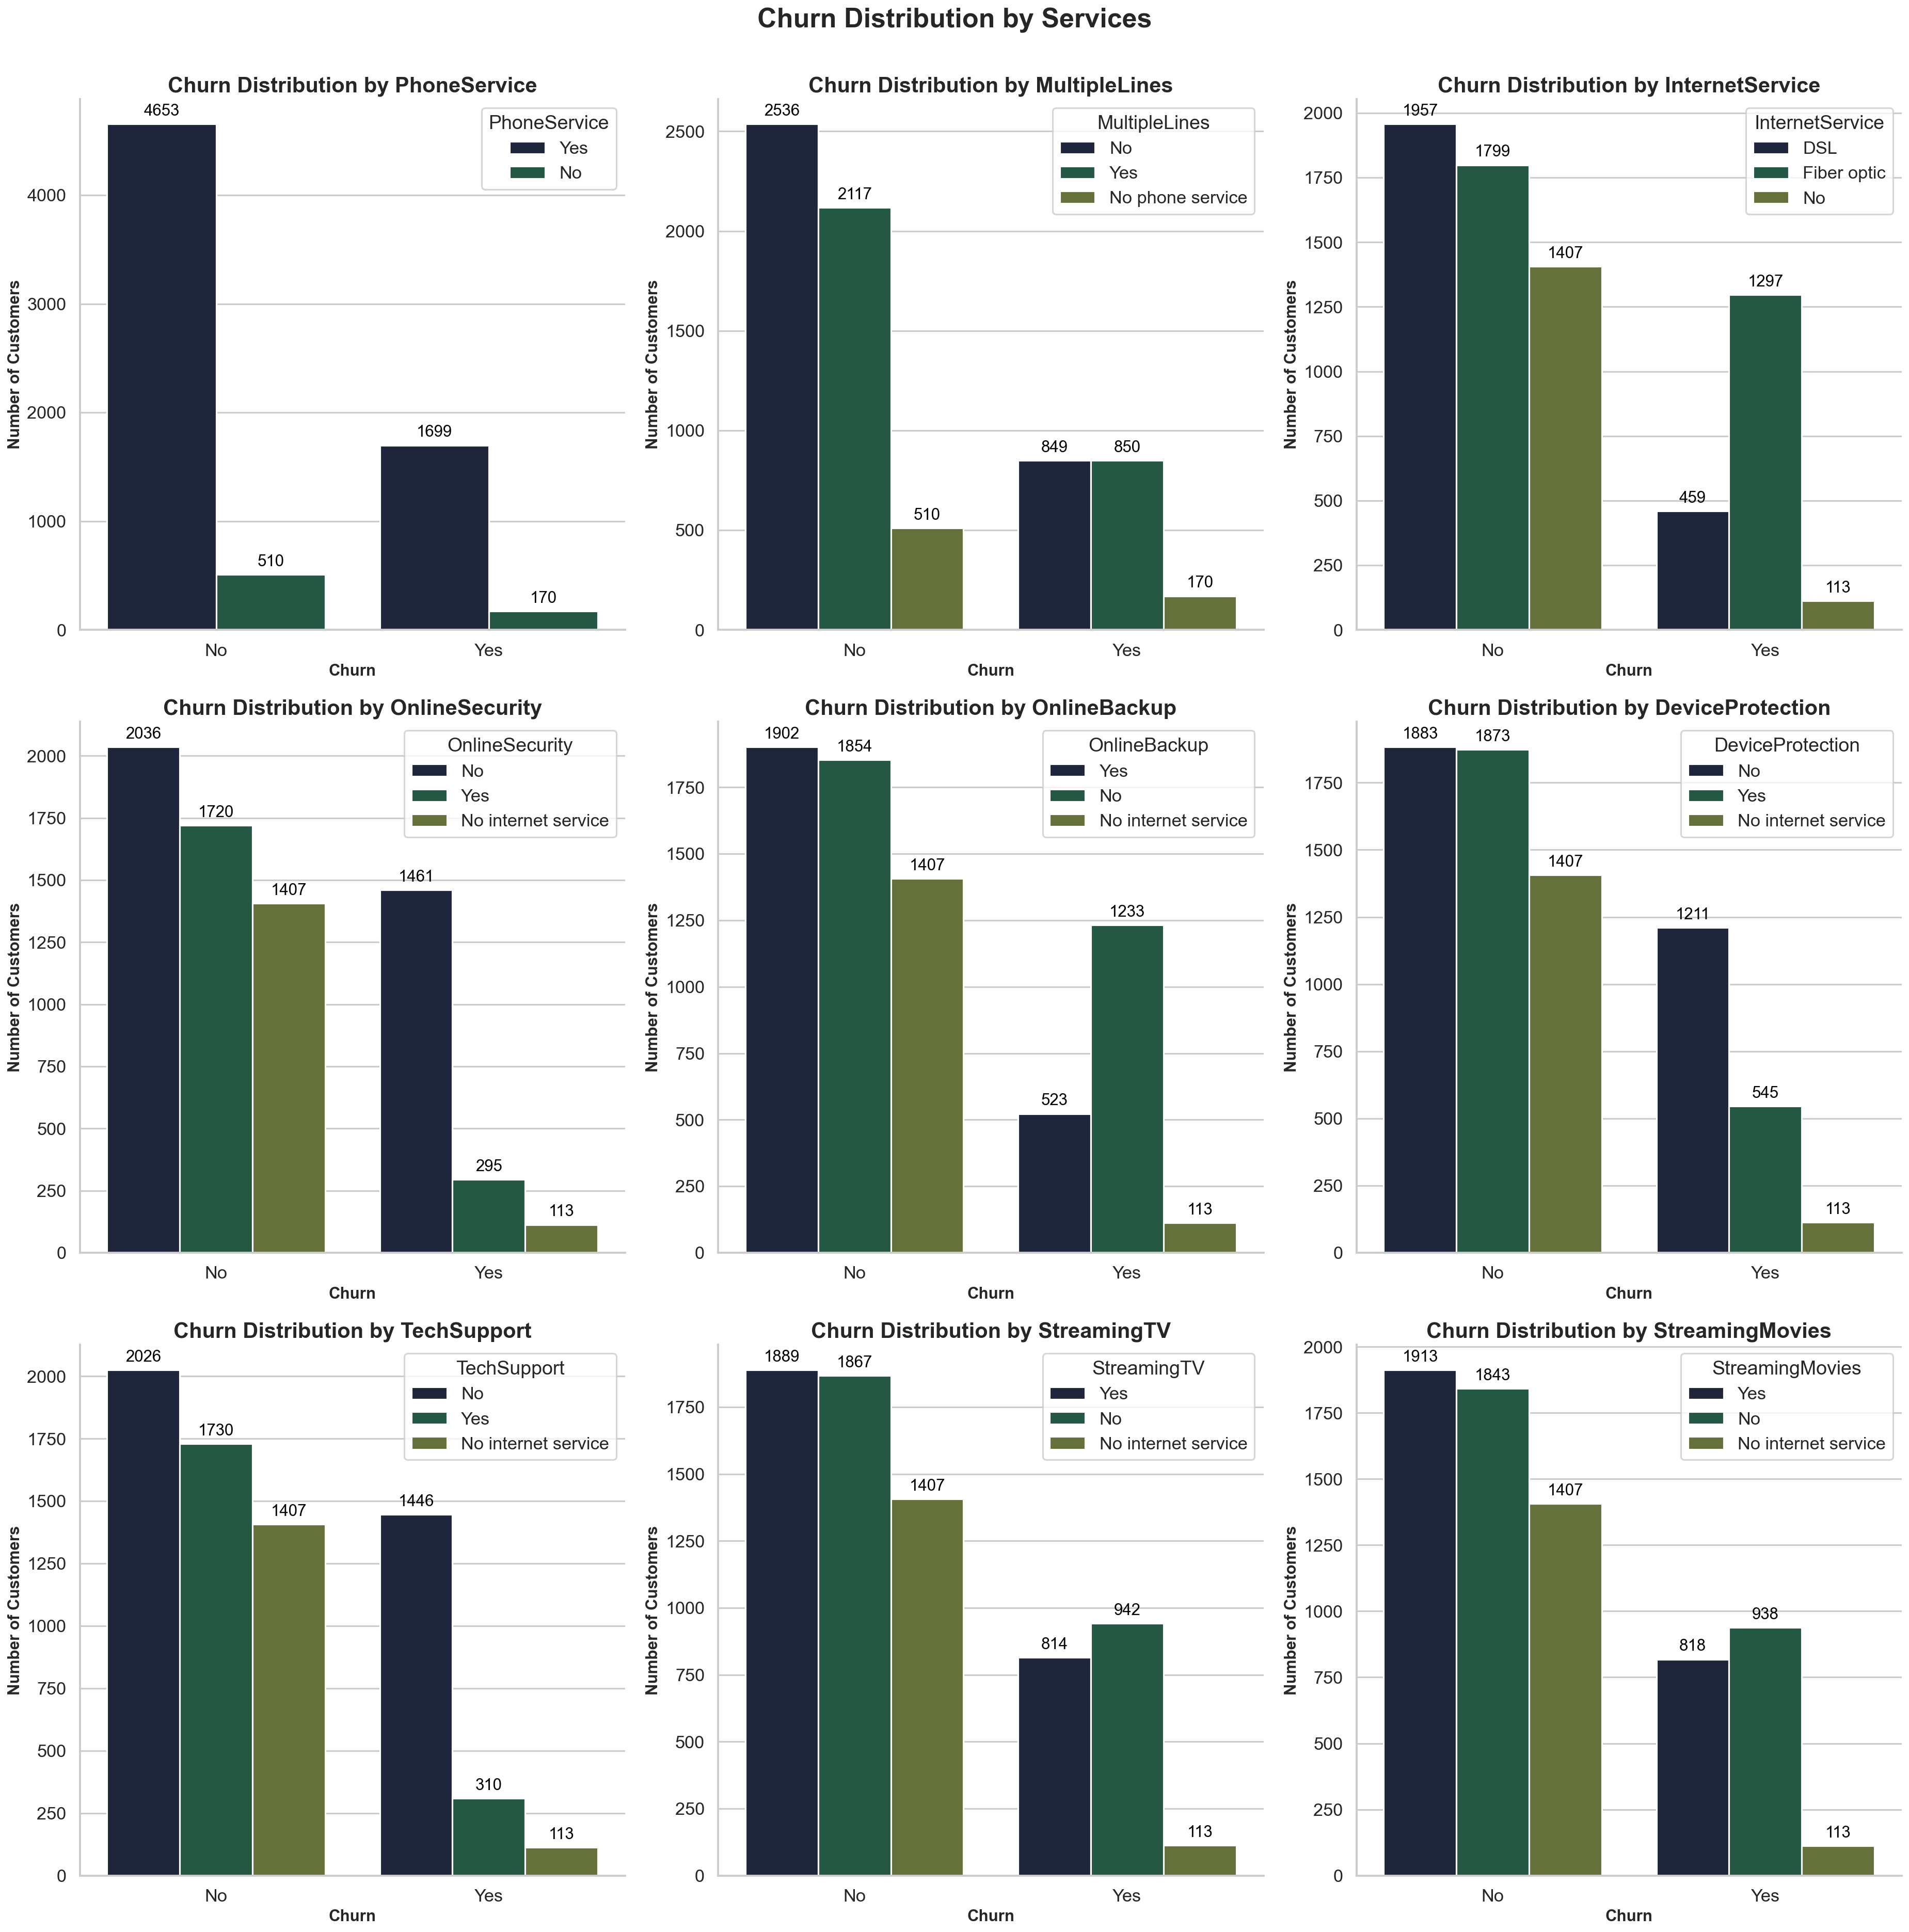

In [94]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25,25))
flatted_axes = axes.flatten()

for col, ax in zip(service_columns, flatted_axes):
    churn_by_service = df.groupby('Churn')[col].value_counts().reset_index(name='count')
    
    sns.barplot(data=churn_by_service, x='Churn', y='count', hue=col, ax=ax)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(int(height), ((p.get_x() + p.get_width() / 2), height),
                        ha='center', va='bottom', fontsize=15, color="black", xytext=(0,5), textcoords="offset points")
    
    ax.set_title(f"Churn Distribution by {col}", fontsize=20, fontweight="bold")
    ax.set_xlabel('Churn', fontweight="bold", fontsize=15)
    ax.set_ylabel("Number of Customers", fontweight="bold", fontsize=15)

fig.suptitle("Churn Distribution by Services", fontsize=25, fontweight="bold", y=1.001)
sns.despine()
plt.tight_layout()
plt.show()

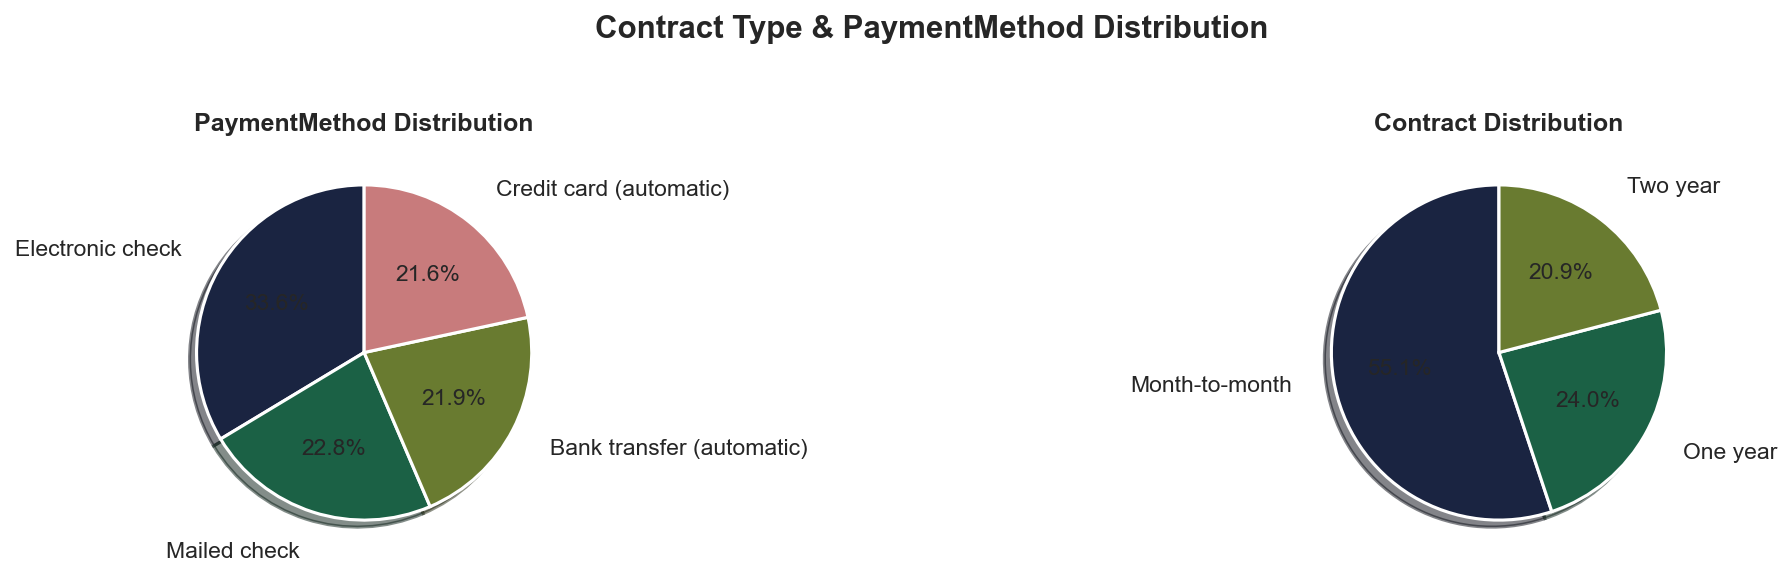

In [95]:
columns_to_count_values = ['PaymentMethod', 'Contract']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,4))
flatted_axes = axes.flatten()

for col, ax in zip(columns_to_count_values, flatted_axes):
    column_values = df[col].value_counts()
    column_labels = df[col].unique()
    
    ax.pie(column_values, labels=column_labels, autopct='%1.1f%%', shadow=True, startangle=90, 
           textprops={'fontsize': 11}, labeldistance=1.25)
    
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    
fig.suptitle("Contract Type & PaymentMethod Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

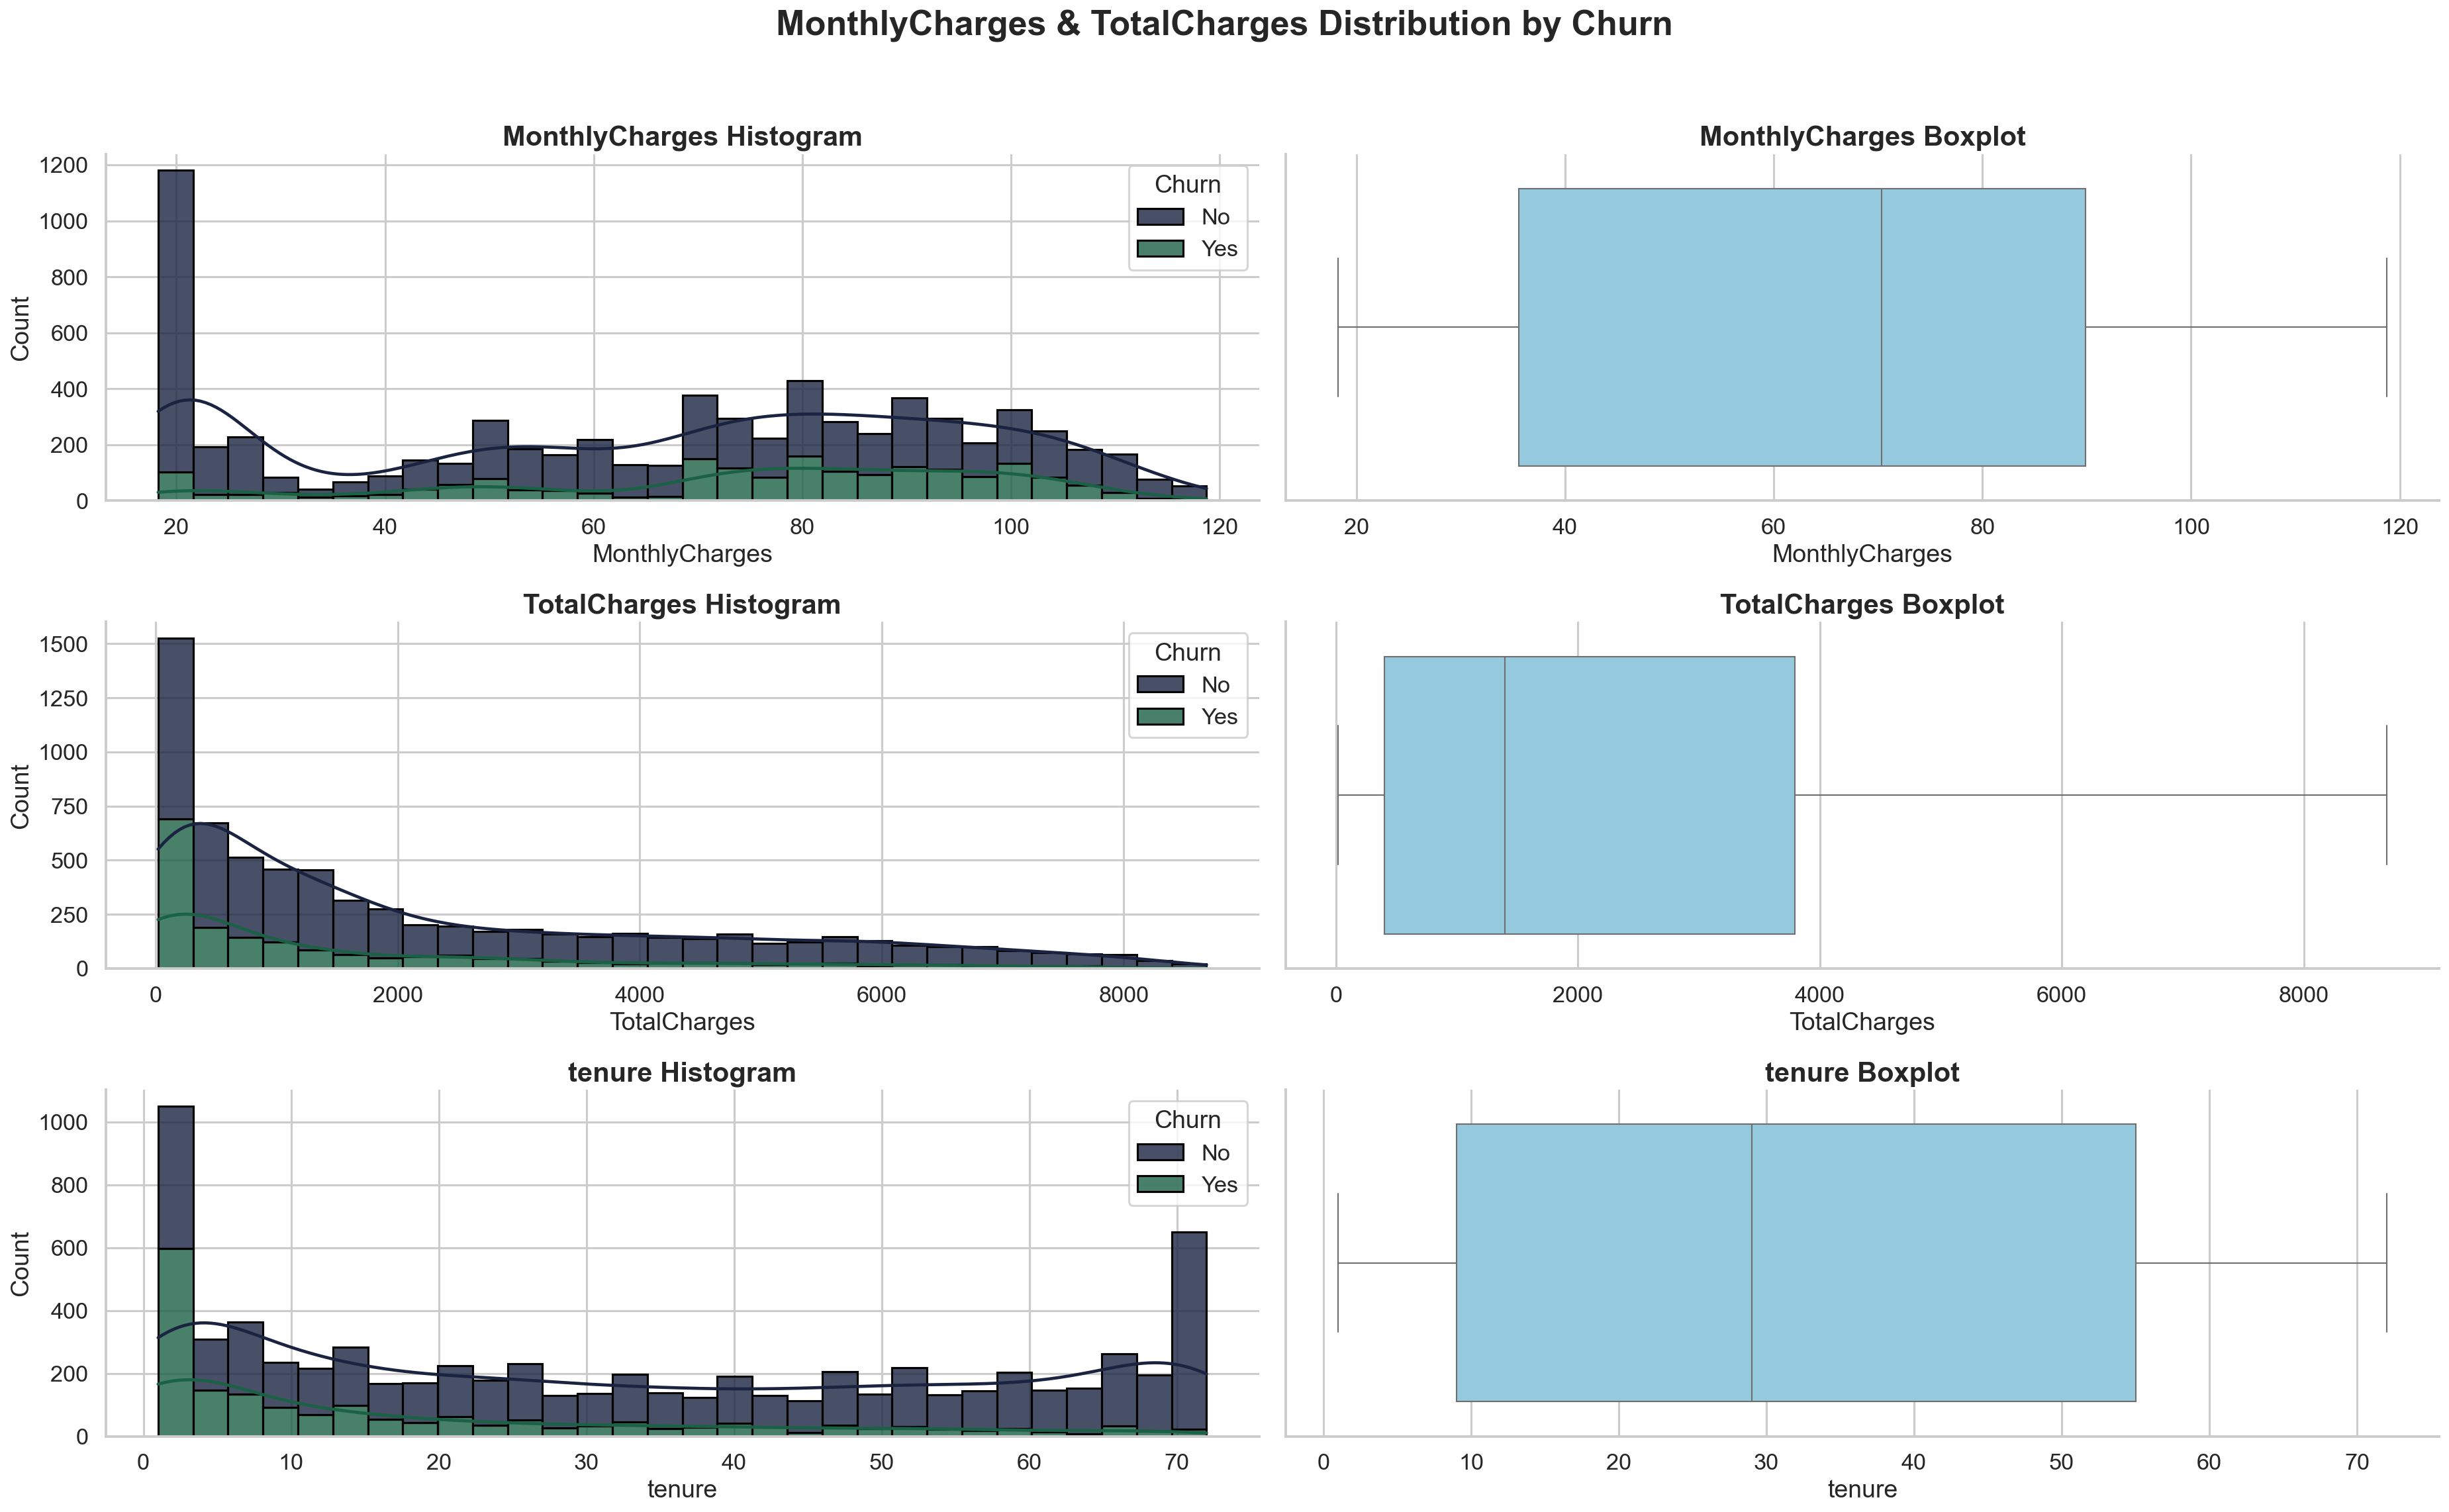

In [96]:
columns_to_visualise = ['MonthlyCharges', 'TotalCharges', 'tenure']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25,15))
axes = axes.flatten()

for i, col in enumerate(columns_to_visualise):
    sns.histplot(
        data=df, x=col, hue="Churn",
        bins=30,
        multiple="stack",
        edgecolor="black",
        alpha=0.8,      
        ax=axes[2*i],
        kde=True
    )
    ax.set_title(f'{col} Distribution by Churn', fontsize=20, fontweight='bold')
    axes[2*i].set_title(f'{col} Histogram', fontsize=20, fontweight='bold')

    sns.boxplot(x=df[col], ax=axes[2*i+1], color="skyblue")
    axes[2*i+1].set_title(f'{col} Boxplot', fontsize=20, fontweight='bold')

fig.suptitle("MonthlyCharges & TotalCharges Distribution by Churn", fontsize=25, fontweight="bold", y=1.02)
plt.tight_layout()
sns.despine()
plt.show()

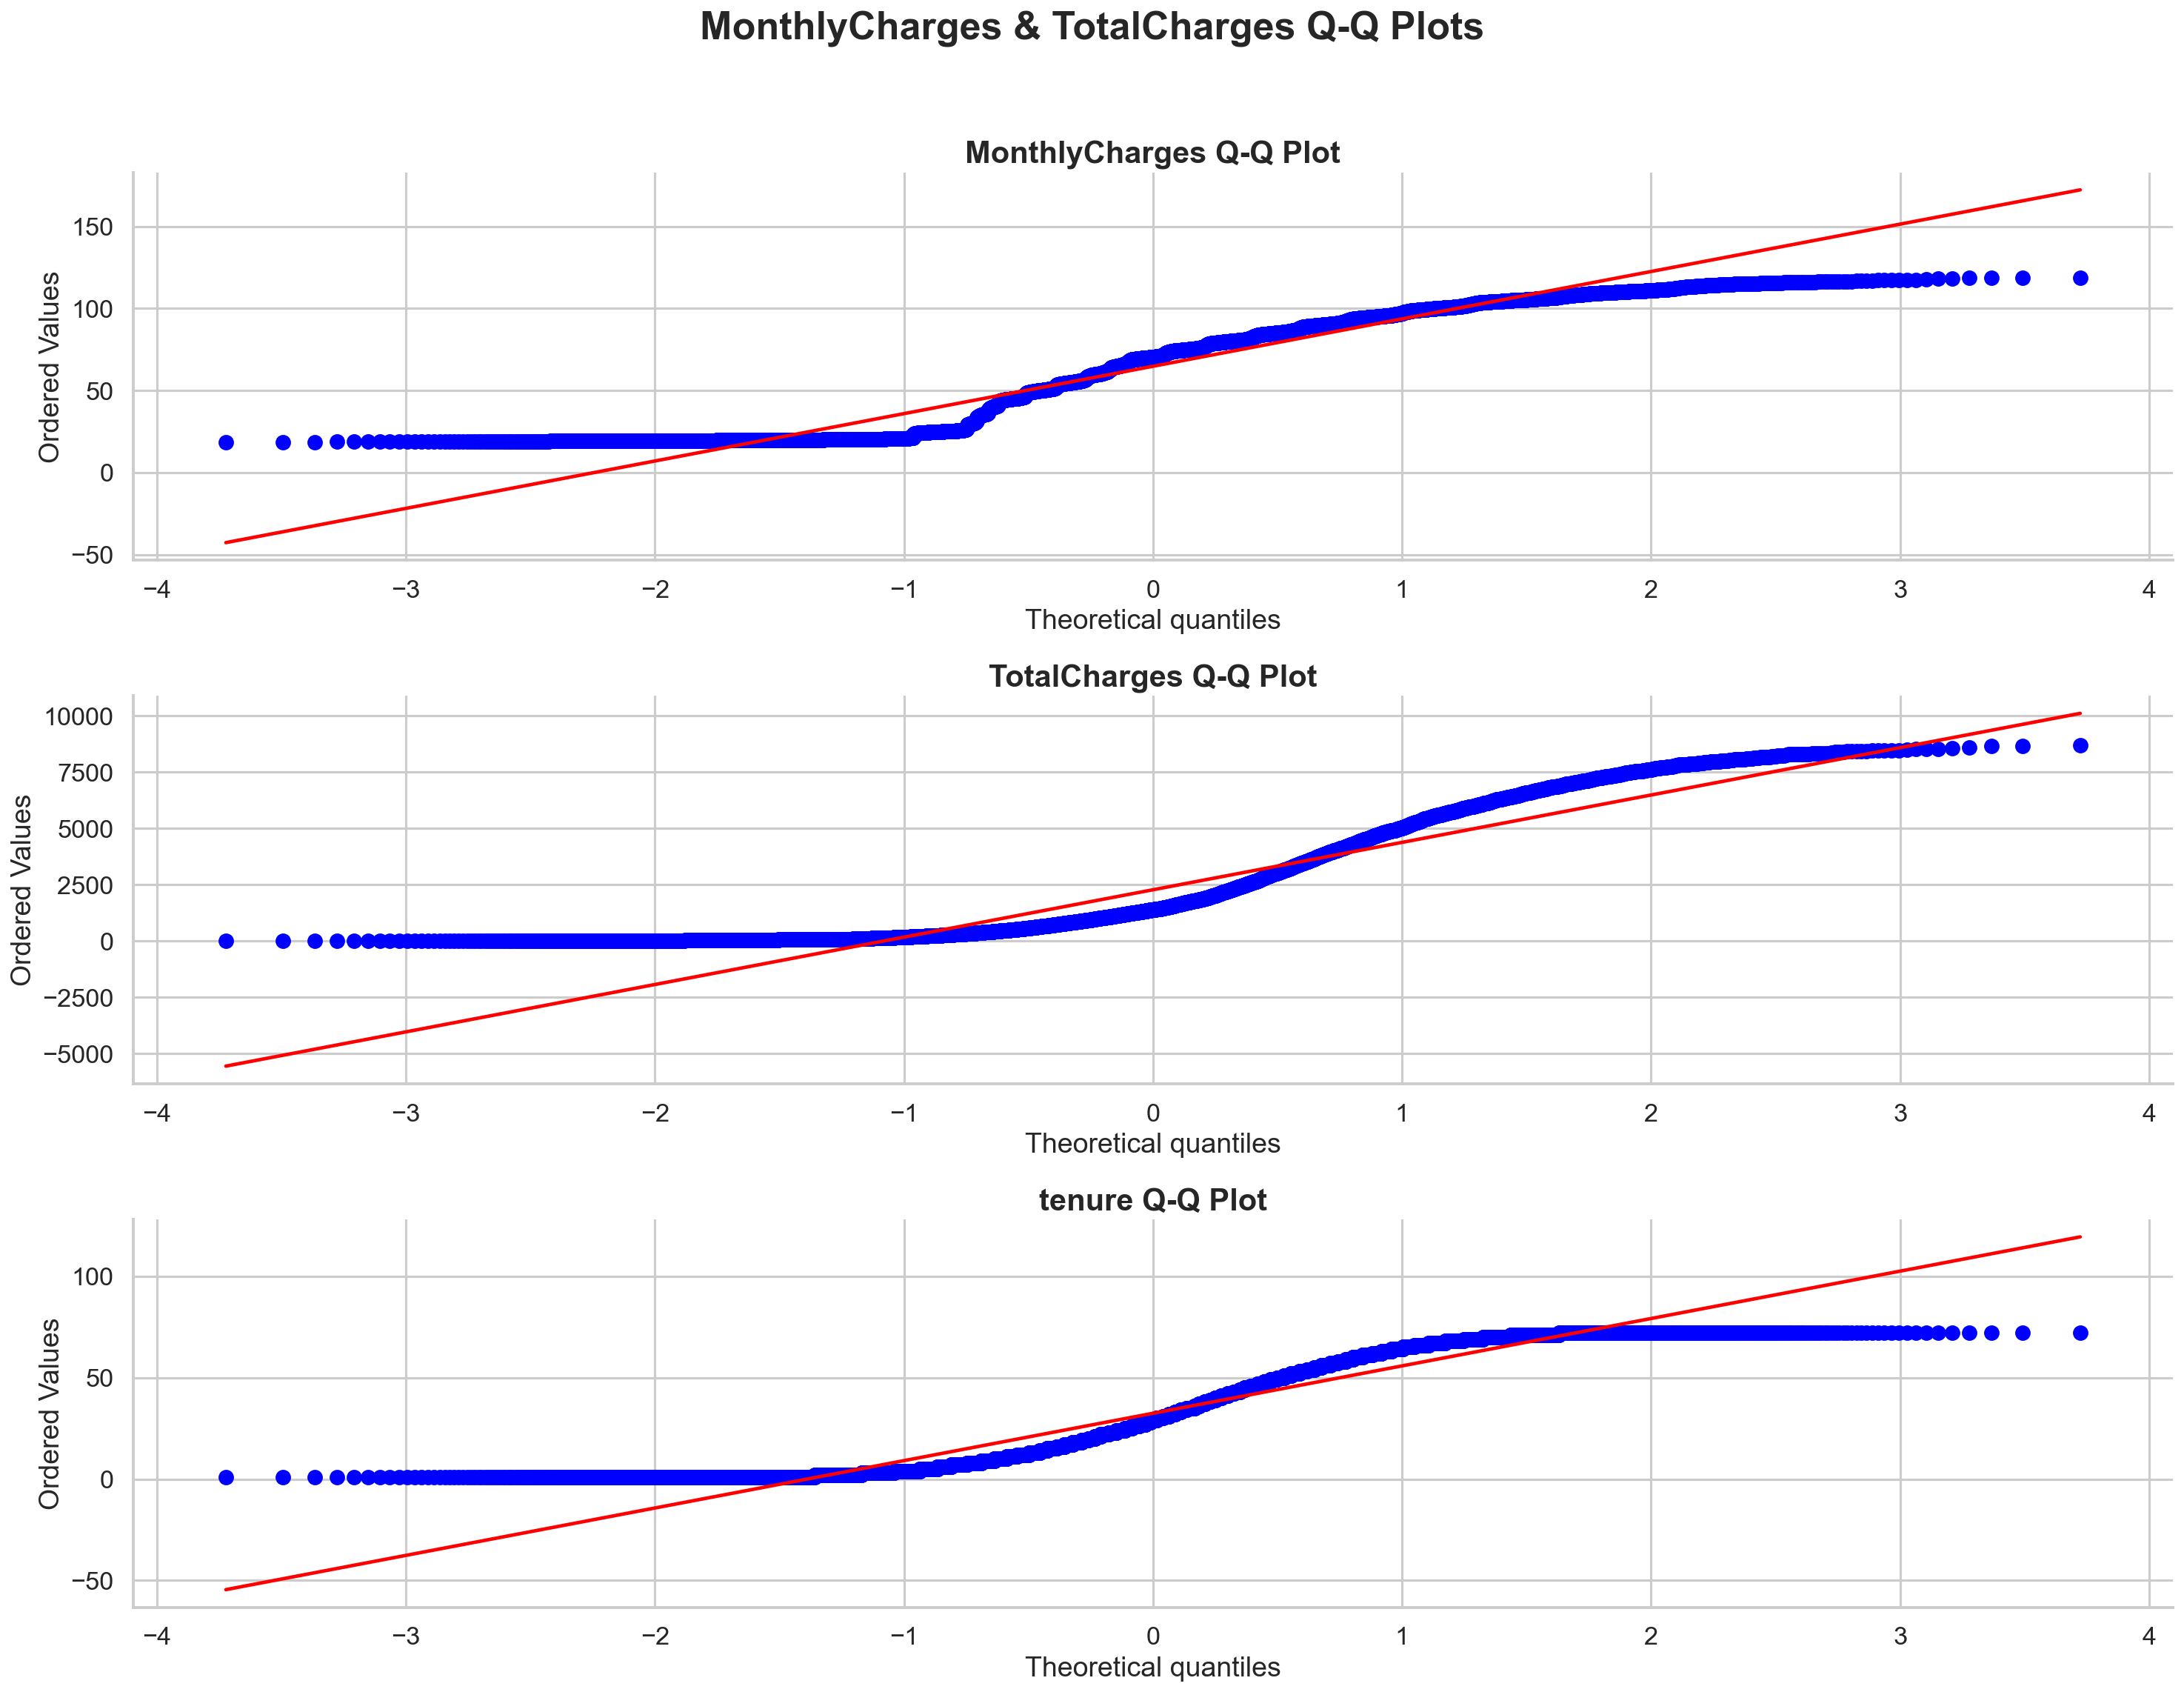

In [97]:
columns_to_visualise = ['MonthlyCharges', 'TotalCharges', 'tenure']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20,15))
axes = axes.flatten()

for i, col in enumerate(columns_to_visualise):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'{col} Q-Q Plot', fontsize=20, fontweight='bold')
    
fig.suptitle("MonthlyCharges & TotalCharges Q-Q Plots", fontsize=25, fontweight="bold", y=1.02)
plt.tight_layout()
sns.despine()
plt.show()

In [98]:
df_copy = df.copy()

X = df_copy.drop(
    ['Churn', 'PaperlessBilling', 'StreamingMovies',
     'PaymentMethod', 'gender', 'StreamingTV'],
    axis=1, errors='ignore'
)
y = df_copy['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

num_cols_train = X_train.select_dtypes(include=['number']).columns.tolist()

transformer = YeoJohnsonTransformer(variables=num_cols_train)
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

scaler = MinMaxScaler()
X_train[num_cols_train] = scaler.fit_transform(X_train[num_cols_train])
X_test[num_cols_train]  = scaler.transform(X_test[num_cols_train])

string_columns = X_train.select_dtypes(include=['object']).columns.tolist()

oh_encoder = OneHotEncoder(variables=string_columns, drop_last=True, drop_last_binary=True)
X_train = oh_encoder.fit_transform(X_train)
X_test  = oh_encoder.transform(X_test)

X_train.head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen_No,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,MultipleLines_No phone service,InternetService_Fiber optic,...,OnlineSecurity_Yes,OnlineSecurity_No,OnlineBackup_Yes,OnlineBackup_No,DeviceProtection_Yes,DeviceProtection_No,TechSupport_Yes,TechSupport_No,Contract_Two year,Contract_Month-to-month
1413,0.944556,0.767535,0.889265,1,1,1,1,1,0,1,...,1,0,1,0,1,0,1,0,1,0
7003,0.549254,0.181909,0.465410,1,0,0,0,0,1,0,...,0,1,0,1,1,0,1,0,0,1
3355,0.968694,0.725214,0.899797,1,1,0,1,1,0,1,...,0,1,1,0,1,0,1,0,1,0
4494,0.090116,0.667614,0.236071,1,0,0,1,0,0,1,...,0,1,1,0,0,1,0,1,0,1
3541,0.804289,0.232190,0.610443,1,1,0,0,0,1,0,...,1,0,0,1,0,1,0,1,0,1


In [99]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_dict = dict({0: weights[0], 1: weights[1]})

svc = SVC(random_state=42, verbose=False)

cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

svc_param_dist = {
    'C': [0.1, 1, 10, 100, 1000],
    'kernel': ['linear', 'poly', 'rbf'],
    'degree': [1, 2, 3, 4, 5, 6, 7],
    'gamma': [0.00001, 0.0001, 0.001],
    'max_iter': [15000, 20000, 25000],
    'class_weight': [weights_dict, {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 1.5}]
}

search_cv = RandomizedSearchCV(estimator=svc, param_distributions=svc_param_dist, 
                               n_iter=70, cv=cv, scoring='roc_auc', random_state=42, verbose=False, error_score='raise')
search_cv.fit(X_train, y_train.values.ravel())
svc_best_model = search_cv.best_estimator_
svc_best_params = search_cv.best_params_

print('Best Parameters:', svc_best_params)
print('Best Score:', search_cv.best_score_, '\n')

Best Parameters: {'max_iter': 20000, 'kernel': 'linear', 'gamma': 1e-05, 'degree': 7, 'class_weight': {0: 1, 1: 2}, 'C': 10}
Best Score: 0.8480340174745817 



ROC AUC Score: 0.7521263543699623
F1 Score: 0.7164286536911206
Accuracy Score: 0.7512437810945274


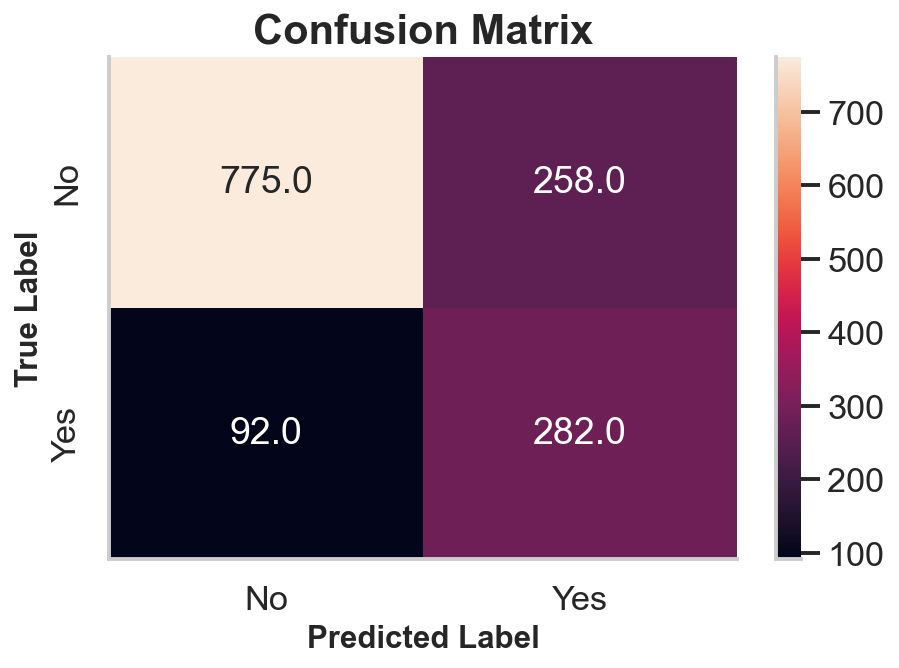

In [100]:
y_pred = svc_best_model.predict(X_test)

auc_score = roc_auc_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
accuracy = accuracy_score(y_test, y_pred) 
matrix = confusion_matrix(y_test, y_pred)

print(f'ROC AUC Score: {auc_score}')
print(f'F1 Score: {f1_macro}')
print("Accuracy Score:", accuracy)

labels = ['No', 'Yes']

sns.heatmap(matrix, annot=True, fmt='0.1f', xticklabels=labels, yticklabels=labels)
sns.despine()
plt.title("Confusion Matrix", fontsize=20, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=15, fontweight="bold")
plt.ylabel("True Label", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()